# Text-aware DTD — shared-backbone OCR head + proposal losses

One image encode, two heads. A **text head reads the Visual Perception Head (VPH) features** and
predicts the text mask *inside* the network; that mask is fused into the decoder. **No second RGB
backbone and no external OCR at inference** — a pretrained OCR is used only to supervise the head
during training, so limited data is not a constraint.

**Protocol:** train/val from `DocTamperV1-TrainingSet` (2000 / 200), test on
`DocTamperV1-TestingSet` (200). Disjoint manifests, seed 42.

**Loss** (proposal §3): `L = CE + λ_dice·Dice + λ_bound·Boundary` for tampering,
plus `λ_text·BCE` for the text head. The λ's are ablated.

**Controls learned the hard way** (each fixed a real artefact):
1. DTD backbone frozen — it already trained on TrainingSet, so fine-tuning it degrades it.
2. Backbone kept in `eval()` — `requires_grad=False` does *not* freeze BatchNorm running stats.
3. Fusion identity-initialised (zeroed final BN + linear merge) — step 0 equals the frozen checkpoint.
4. Val-based selection — an arm can never end below the baseline.

In [2]:
# --- CONFIG ---
from pathlib import Path

CONFIG = {
    'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
    'PROJECT_BRANCH': 'main',
    'PROJECT_DIR': '/content/HLCV-Project',
    'DOCTAMPER_DIR': '/content/DocTamper',

    'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',       # shared (read)
    'OUT_ROOT':       '/content/drive/MyDrive/HLCV_samira/ta_design',  # yours (write)
    'MANIFEST_DIR':   '/content/drive/MyDrive/HLCV_samira/manifests/ta_train2000_val200_test200_seed42',
    'DRIVE_ZIP':      '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
    'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
    'DATA_ROOT':      '/content/doctamper_train_test',

    'SEED': 42,
    'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
    'TEST_SOURCE':  'DocTamperV1-TestingSet',
    'TRAIN_SIZE': 2000, 'VAL_SIZE': 200, 'TEST_SIZE': 200,

    'BATCH_SIZE': 2, 'TRAIN_STEPS': 600, 'ADAPTER_LR': 1e-4, 'WEIGHT_DECAY': 1e-2,
    'EVAL_EVERY': 100, 'PATIENCE': 3,
    'JPEG_QUALITY': 75, 'EVAL_THRESHOLD': 0.5, 'IMG': 512,
    'LAMBDA_TEXT': 0.5,                 # weight of the text-head BCE
    'TEXT_FEAT_IDX': 0,                 # which VPH feature the text head reads

    # Pretrained OCR used ONLY to supervise the text head (training) and as the reference
    # detector when measuring the head's precision/recall.
    'OCR_BACKEND': 'easyocr', 'OCR_DILATION': 2, 'OCR_CONFIDENCE_THRESHOLD': 0.0,
    'INIT_CHECKPOINT': 'dtd_doctamper.pth',
}
CONFIG

{'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
 'PROJECT_BRANCH': 'main',
 'PROJECT_DIR': '/content/HLCV-Project',
 'DOCTAMPER_DIR': '/content/DocTamper',
 'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',
 'OUT_ROOT': '/content/drive/MyDrive/HLCV_samira/ta_design',
 'MANIFEST_DIR': '/content/drive/MyDrive/HLCV_samira/manifests/ta_train2000_val200_test200_seed42',
 'DRIVE_ZIP': '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
 'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
 'DATA_ROOT': '/content/doctamper_train_test',
 'SEED': 42,
 'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
 'TEST_SOURCE': 'DocTamperV1-TestingSet',
 'TRAIN_SIZE': 2000,
 'VAL_SIZE': 200,
 'TEST_SIZE': 200,
 'BATCH_SIZE': 2,
 'TRAIN_STEPS': 600,
 'ADAPTER_LR': 0.0001,
 'WEIGHT_DECAY': 0.01,
 'EVAL_EVERY': 100,
 'PATIENCE': 3,
 'JPEG_QUALITY': 75,
 'EVAL_THRESHOLD': 0.5,
 'IMG': 512,
 'LAMBDA_TEXT': 0.5,
 'TEXT_FEAT_IDX': 0,
 'OCR_BACKEND': 'easyocr',
 'OCR_DILATION': 2,
 'OCR_C

In [3]:
# --- Setup ---
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess
assert Path(CONFIG['CHECKPOINT_DIR']).exists(), (
    f"Not found: {CONFIG['CHECKPOINT_DIR']} -- add the shared HLCV folder shortcut to My Drive.")

%cd /content
if not Path(CONFIG['PROJECT_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', '-b', CONFIG['PROJECT_BRANCH'],
                    CONFIG['PROJECT_REPO_URL'], CONFIG['PROJECT_DIR']], check=True)
if not Path(CONFIG['DOCTAMPER_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', 'https://github.com/qcf-568/DocTamper.git',
                    CONFIG['DOCTAMPER_DIR']], check=True)

!pip -q install lmdb six albumentations timm==0.4.12 segmentation_models_pytorch==0.2.1 easyocr pytesseract kaggle scikit-learn matplotlib
!pip -q install efficientnet_pytorch==0.7.1
!apt-get -qq install -y tesseract-ocr libjpeg-dev > /dev/null
!pip -q uninstall -y jpegio
!rm -rf /content/jpegio && git clone -q https://github.com/dwgoon/jpegio.git /content/jpegio
%cd /content/jpegio
!pip -q install .
%cd /content/DocTamper/models

sys.path.insert(0, CONFIG['PROJECT_DIR'])
import jpegio
print('jpegio.read:', hasattr(jpegio, 'read'))

Mounted at /content/drive
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 30.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytor

In [4]:
# --- Data (cached zip -> temp disk) + checkpoints + manifests ---
import getpass, shutil
DATA_ROOT = Path(CONFIG['DATA_ROOT']); DATA_ROOT.mkdir(parents=True, exist_ok=True)
need = [DATA_ROOT / CONFIG['TRAIN_SOURCE'] / 'data.mdb', DATA_ROOT / CONFIG['TEST_SOURCE'] / 'data.mdb']

if not all(p.exists() for p in need):
    zp = Path('/content/doctamper_kaggle/doctamper.zip')
    if not zp.exists():
        zp = Path(CONFIG['DRIVE_ZIP'])
    if not zp.exists():
        kdir = Path.home() / '.kaggle'; kdir.mkdir(parents=True, exist_ok=True)
        if not (kdir / 'access_token').exists() and not (kdir / 'kaggle.json').exists():
            (kdir / 'access_token').write_text(getpass.getpass('Paste Kaggle API token: ').strip())
            (kdir / 'access_token').chmod(0o600)
        zp = Path('/content/doctamper_kaggle/doctamper.zip'); zp.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(['kaggle', 'datasets', 'download', '-d', CONFIG['KAGGLE_DATASET'],
                        '-p', str(zp.parent)], check=True)
    for pat in [f"{CONFIG['TRAIN_SOURCE']}/*", f"{CONFIG['TEST_SOURCE']}/*"]:
        print('extracting', pat)
        subprocess.run(['unzip', '-o', '-q', str(zp), pat, '-d', str(DATA_ROOT)], check=True)
for p in need:
    assert p.exists(), f'Missing {p}'

%cd /content/DocTamper/models
if not Path('qt_table.pk').exists():
    shutil.copy2(Path(CONFIG['DOCTAMPER_DIR']) / 'qt_table.pk', 'qt_table.pk')
for f in ['vph_imagenet.pt', 'swin_imagenet.pt', CONFIG['INIT_CHECKPOINT']]:
    if not Path(f).exists():
        srcp = Path(CONFIG['CHECKPOINT_DIR']) / f
        assert srcp.exists(), f'Missing {srcp}'
        shutil.copy2(srcp, f); print('staged', f)

MAN = Path(CONFIG['MANIFEST_DIR'])
if not (MAN / 'test.json').exists():
    cmd = [sys.executable, f"{CONFIG['PROJECT_DIR']}/scripts/generate_doctamper_subset.py",
           '--data-root', str(DATA_ROOT), '--output-dir', str(MAN), '--seed', str(CONFIG['SEED']),
           '--train-source', CONFIG['TRAIN_SOURCE'], '--test-source', CONFIG['TEST_SOURCE'],
           '--train-size', str(CONFIG['TRAIN_SIZE']), '--val-size', str(CONFIG['VAL_SIZE']),
           '--test-size', str(CONFIG['TEST_SIZE'])]
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout)
    if r.returncode != 0:
        raise RuntimeError(r.stderr)
for s in ['train', 'val', 'test']:
    assert (MAN / f'{s}.json').exists()
print('manifests ready:', MAN)

extracting DocTamperV1-TrainingSet/*
extracting DocTamperV1-TestingSet/*
/content/DocTamper/models
staged vph_imagenet.pt
staged swin_imagenet.pt
staged dtd_doctamper.pth
manifests ready: /content/drive/MyDrive/HLCV_samira/manifests/ta_train2000_val200_test200_seed42


In [5]:
# --- Model, losses, loaders ---
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, json, copy, time
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score

_ORIG_LOAD = torch.load
torch.load = lambda *a, **k: _ORIG_LOAD(*a, **{**k, 'weights_only': False})
from dtd import *                                     # pickled backbone classes into __main__
from src.losses import CombinedTamperLoss
from src.fusion import TextPriorFusion
from src.doctamper_dataset import ManifestDocTamperDataset
from src.ocr_backends import OCRConfig, create_ocr_backend
from src.ocr_cache import OCRDetectionCache
from src.ocr_eval import OCRCoverageMeter

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(CONFIG['SEED']); np.random.seed(CONFIG['SEED'])
OUT = Path(CONFIG['OUT_ROOT']); OUT.mkdir(parents=True, exist_ok=True)
IMG = CONFIG['IMG']

def make_loader(split, shuffle):
    ds = ManifestDocTamperDataset(DATA_ROOT, MAN / f'{split}.json', 'qt_table.pk', CONFIG['JPEG_QUALITY'])
    return DataLoader(ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=shuffle,
                      num_workers=0, drop_last=shuffle)
train_loader, val_loader, test_loader = make_loader('train', True), make_loader('val', False), make_loader('test', False)
print(f'train {len(train_loader.dataset)} | val {len(val_loader.dataset)} | test {len(test_loader.dataset)}')

def build_model():
    m = seg_dtd('', 2).to(DEVICE)
    for mod in m.modules():                            # old pickles predate nn.GELU.approximate
        if isinstance(mod, nn.GELU) and not hasattr(mod, 'approximate'):
            mod.approximate = 'none'
    sd = torch.load(CONFIG['INIT_CHECKPOINT'], map_location='cpu')['state_dict']
    m.load_state_dict({k.replace('module.', ''): v for k, v in sd.items()}, strict=False)
    return m

def forward_dtd(model, batch):
    return model(batch['image'].to(DEVICE), batch['rgb'].to(DEVICE), batch['q'].unsqueeze(1).to(DEVICE))

MEAN = np.array([0.485, 0.455, 0.406]); STD = np.array([0.229, 0.224, 0.225])
def denorm(t):
    a = t.permute(1, 2, 0).cpu().numpy() * STD + MEAN
    return np.clip(a * 255, 0, 255).astype(np.uint8)
print('model helpers ready | device', DEVICE)

/content/DocTamper/models/dtd.py:320: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast()


train 2000 | val 200 | test 200
model helpers ready | device cuda


In [6]:
# --- Pretrained OCR: supervision for the text head (training) + reference detector (eval) ---
# This is the ONLY place a pretrained OCR is used. It never runs at inference.
ocr_cfg = OCRConfig(backend=CONFIG['OCR_BACKEND'], languages=('en',),
                    confidence_threshold=CONFIG['OCR_CONFIDENCE_THRESHOLD'],
                    dilation=CONFIG['OCR_DILATION'], easyocr_gpu=(DEVICE == 'cuda'))
ocr_backend = create_ocr_backend(ocr_cfg)
ocr_cache = OCRDetectionCache(OUT / 'ocr_cache', ocr_cfg)

def ocr_masks(batch):
    """Pretrained-OCR text masks for a batch -> (B,1,H,W) float on device (cached per sample)."""
    out = []
    for t, sid in zip(batch['image'], batch['sample_id']):
        img = denorm(t)
        det, _ = ocr_cache.get_or_compute(sid, img, ocr_backend)
        out.append(ocr_cache.mask_from_detections(det, img.shape))
    return torch.from_numpy(np.stack(out)[:, None]).float().to(DEVICE)

t0 = time.time()
_ = ocr_masks(next(iter(train_loader)))
print(f'OCR pseudo-labeller ready ({CONFIG["OCR_BACKEND"]}), first batch {time.time()-t0:.1f}s')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR pseudo-labeller ready (easyocr), first batch 9.1s


In [7]:
# --- ARCHITECTURE (TA's design): text head on shared VPH features + decoder fusion ---
class TextHead(nn.Module):
    """Lightweight text-detection head on a shared VPH feature map -> 1-channel text logits."""
    def __init__(self, in_ch, mid=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.Conv2d(mid, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.Conv2d(mid, 1, 1))
    def forward(self, x): return self.net(x)

class HeadWithPrior(nn.Module):
    """Fuse the predicted text mask into the final decoder feature, then run the seg head."""
    def __init__(self, head, in_ch):
        super().__init__()
        self.fusion = TextPriorFusion(in_ch); self.head = head; self.text_mask = None
    def forward(self, feat):
        return self.head(self.fusion(feat, self.text_mask))

def probe_vph(model):
    """Report the VPH output feature shapes (one forward, no grad)."""
    grabbed = {}
    h = model.model.vph.register_forward_hook(lambda m, i, o: grabbed.update(o=o))
    with torch.no_grad():
        _ = forward_dtd(model, next(iter(val_loader)))
    h.remove()
    feats = list(grabbed['o']) if isinstance(grabbed['o'], (list, tuple)) else [grabbed['o']]
    for i, f in enumerate(feats):
        print(f'  vph feat[{i}] channels={f.shape[1]} spatial={tuple(f.shape[-2:])}')
    return feats

def wire_ocr_head(model, feat_idx, c_vph):
    """One backbone, two heads. A forward hook on vph computes the text mask from the SHARED
    features and feeds it to the decoder fusion -- no second RGB backbone, no OCR at inference."""
    core = model.model
    if hasattr(core, '_ta_hook'):
        core._ta_hook.remove()
    core.text_head = TextHead(c_vph).to(DEVICE)

    head = core.segmentation_head
    while hasattr(head, 'head'):
        head = head.head
    hp = HeadWithPrior(head, head[0].in_channels).to(DEVICE)
    nn.init.zeros_(hp.fusion.block[-1].weight)         # identity init: block(...) == 0
    nn.init.zeros_(hp.fusion.block[-1].bias)
    hp.fusion.act = nn.Identity()                      # linear merge so identity is reachable
    core.segmentation_head = hp

    def hook(m, i, o):
        feats = list(o) if isinstance(o, (list, tuple)) else [o]
        t = core.text_head(feats[feat_idx])
        t = F.interpolate(t, size=(IMG, IMG), mode='bilinear', align_corners=False)
        core._text_logits = t
        core.segmentation_head.text_mask = torch.sigmoid(t)
    core._ta_hook = core.vph.register_forward_hook(hook)
    return core

def adapter_params(model):
    """Freeze the pretrained DTD; train only the two NEW modules."""
    core = model.model
    for p in model.parameters():
        p.requires_grad_(False)
    for p in core.text_head.parameters():
        p.requires_grad_(True)
    for p in core.segmentation_head.fusion.parameters():
        p.requires_grad_(True)
    return [p for p in model.parameters() if p.requires_grad]

def set_train_mode(model):
    """Backbone eval() so its BatchNorm running stats stay frozen; new modules train()."""
    model.eval()
    model.model.text_head.train()
    model.model.segmentation_head.fusion.train()

print('architecture ready')

architecture ready


In [8]:
# --- evaluate() and the joint-loss training loop ---
@torch.no_grad()
def evaluate(model, loader, keep_frac=0.05, seed=0):
    """No external OCR: the text head supplies the mask via its hook (or there is no prior)."""
    model.eval(); rng = np.random.default_rng(seed)
    tp = fp = fn = 0; probs, labels = [], []
    for batch in loader:
        target = batch['label'].squeeze(1).long().to(DEVICE)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
        prob = torch.softmax(logits.float(), 1)[:, 1]
        pred, gt = prob > CONFIG['EVAL_THRESHOLD'], target.bool()
        tp += (pred & gt).sum().item(); fp += (pred & ~gt).sum().item(); fn += (~pred & gt).sum().item()
        p = prob.flatten().cpu().numpy(); l = gt.flatten().cpu().numpy()
        idx = rng.choice(len(p), max(1, int(len(p) * keep_frac)), replace=False)
        probs.append(p[idx].astype(np.float32)); labels.append(l[idx].astype(np.uint8))
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    y, s = np.concatenate(labels), np.concatenate(probs)
    return ({'pixel_f1': 2 * prec * rec / (prec + rec + 1e-9), 'precision': prec, 'recall': rec,
             'iou': tp / (tp + fp + fn + 1e-9),
             'auc': float(roc_auc_score(y, s)) if y.min() != y.max() else float('nan')}, y, s)

bce = nn.BCEWithLogitsLoss()

def train_adapter(model, criterion, steps, tag=''):
    """Joint loss: tampering (CE + Dice + Boundary) + LAMBDA_TEXT * BCE(text head, OCR pseudo-label)."""
    core = model.model
    params = adapter_params(model)
    opt = torch.optim.AdamW(params, lr=CONFIG['ADAPTER_LR'], weight_decay=CONFIG['WEIGHT_DECAY'])
    scaler = GradScaler(); it = iter(train_loader)

    m0, _, _ = evaluate(model, val_loader)                      # identity init => frozen checkpoint
    snap = lambda: {'text': copy.deepcopy(core.text_head.state_dict()),
                    'fus': copy.deepcopy(core.segmentation_head.fusion.state_dict())}
    best = {'f1': m0['pixel_f1'], 'step': 0, 'state': snap()}
    print(f"  [{tag}] trainable {sum(p.numel() for p in params):,} | val@0000 f1={m0['pixel_f1']:.4f}")
    stale = 0
    set_train_mode(model)
    for step in range(steps):
        try: batch = next(it)
        except StopIteration: it = iter(train_loader); batch = next(it)
        pseudo = ocr_masks(batch)                                # pretrained-OCR supervision
        target = batch['label'].squeeze(1).long().to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)                   # hook sets core._text_logits
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            tamper_loss, parts = criterion(logits, target)
            text_loss = bce(core._text_logits.float(), pseudo)
            loss = tamper_loss + CONFIG['LAMBDA_TEXT'] * text_loss
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        if (step + 1) % CONFIG['EVAL_EVERY'] == 0:
            m, _, _ = evaluate(model, val_loader)
            better = m['pixel_f1'] > best['f1']
            print(f"  [{tag}] val@{step+1:04d} f1={m['pixel_f1']:.4f} tamper={float(parts['total']):.4f} "
                  f"text={text_loss.item():.4f}{'  <- best' if better else ''}")
            if better:
                best = {'f1': m['pixel_f1'], 'step': step + 1, 'state': snap()}; stale = 0
            else:
                stale += 1
                if stale >= CONFIG['PATIENCE']:
                    print(f'  [{tag}] early stop at {step+1}'); break
            set_train_mode(model)
    core.text_head.load_state_dict(best['state']['text'])
    core.segmentation_head.fusion.load_state_dict(best['state']['fus'])
    print(f"  [{tag}] restored step {best['step']} (val f1={best['f1']:.4f})")
    return best

print('train/eval ready')

train/eval ready


In [9]:
# --- Arm 1: baseline = frozen DTD checkpoint (no OCR head, no training) ---
results, curves, selection = {}, {}, {}
model = build_model()
print('VPH feature shapes:')
feats = probe_vph(model)
C_VPH = feats[CONFIG['TEXT_FEAT_IDX']].shape[1]
print('text head will read feat[%d] with %d channels' % (CONFIG['TEXT_FEAT_IDX'], C_VPH))

results['baseline (frozen DTD)'], y, s = evaluate(model, test_loader)
curves['baseline (frozen DTD)'] = (y, s)
print('baseline:', {k: round(v, 4) for k, v in results['baseline (frozen DTD)'].items()})
del model; torch.cuda.empty_cache()

VPH feature shapes:


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


  vph feat[0] channels=96 spatial=(128, 128)
  vph feat[1] channels=192 spatial=(64, 64)
  vph feat[2] channels=384 spatial=(32, 32)
  vph feat[3] channels=768 spatial=(16, 16)
text head will read feat[0] with 96 channels


/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


baseline: {'pixel_f1': 0.7795, 'precision': 0.8662, 'recall': 0.7085, 'iou': 0.6387, 'auc': 0.9454}


In [10]:
# --- Arms 2-4: OCR head + loss ablation (proposal: CE, +Dice, +Boundary) ---
LOSS_CONFIGS = {
    '+OCR head, CE only':          (0.0, 0.0),
    '+OCR head, CE+Dice':          (1.0, 0.0),
    '+OCR head, CE+Dice+Boundary': (1.0, 0.5),
}
(OUT / 'arms').mkdir(parents=True, exist_ok=True)

for tag, (ld, lb) in LOSS_CONFIGS.items():
    print(f'=== {tag} (lambda_dice={ld}, lambda_bound={lb}) ===')
    model = build_model()
    wire_ocr_head(model, CONFIG['TEXT_FEAT_IDX'], C_VPH)
    crit = CombinedTamperLoss(lambda_dice=ld, lambda_bound=lb)
    best = train_adapter(model, crit, CONFIG['TRAIN_STEPS'], tag=tag.split(',')[-1].strip())
    selection[tag] = {'val_f1': best['f1'], 'step': best['step']}
    met, y, s = evaluate(model, test_loader)
    results[tag], curves[tag] = met, (y, s)
    torch.save({'text_head': model.model.text_head.state_dict(),
                'fusion': model.model.segmentation_head.fusion.state_dict()},
               OUT / 'arms' / f"{tag.replace(' ', '_').replace('+','').replace(',','')}.pth")
    print(' TEST:', {k: round(v, 4) for k, v in met.items()})
    del model; torch.cuda.empty_cache()

=== +OCR head, CE only (lambda_dice=0.0, lambda_bound=0.0) ===


/tmp/ipykernel_422/3238522890.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(train_loader)
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [CE only] trainable 134,273 | val@0000 f1=0.6100


/tmp/ipykernel_422/3238522890.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [CE only] val@0100 f1=0.6117 tamper=0.0972 text=0.3284  <- best


...

  [CE+Dice+Boundary] val@0500 f1=0.6281 tamper=1.3850 text=0.3788


/tmp/ipykernel_422/3238522890.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [CE+Dice+Boundary] val@0600 f1=0.6303 tamper=1.0271 text=0.3003
  [CE+Dice+Boundary] early stop at 600
  [CE+Dice+Boundary] restored step 300 (val f1=0.6313)


/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.7582, 'precision': 0.7816, 'recall': 0.7361, 'iou': 0.6106, 'auc': 0.9474}


In [11]:
# --- Threshold sweep (F1 at each arm's optimum, not just 0.5) ---
THRESHOLDS = np.linspace(0.05, 0.95, 19)
sweep = {}
for name, (y, s) in curves.items():
    f1s = []
    for t in THRESHOLDS:
        pred = s >= t
        tp = int((pred & (y == 1)).sum()); fp = int((pred & (y == 0)).sum()); fn = int((~pred & (y == 1)).sum())
        p = tp / (tp + fp + 1e-9); r = tp / (tp + fn + 1e-9)
        f1s.append(2 * p * r / (p + r + 1e-9))
    f1s = np.array(f1s); b = int(f1s.argmax())
    sweep[name] = {'thresholds': THRESHOLDS, 'f1s': f1s}
    results[name]['f1_at_best_threshold'] = float(f1s[b])
    results[name]['best_threshold'] = float(THRESHOLDS[b])

print(f'{"arm":<30}{"F1@0.5":>9}{"F1@best":>10}{"best_t":>8}{"IoU":>9}{"AUC":>9}')
for k in results:
    v = results[k]
    print(f"{k:<30}{v['pixel_f1']:>9.4f}{v['f1_at_best_threshold']:>10.4f}"
          f"{v['best_threshold']:>8.2f}{v['iou']:>9.4f}{v['auc']:>9.4f}")

arm                              F1@0.5   F1@best  best_t      IoU      AUC
baseline (frozen DTD)            0.7795    0.7787    0.55   0.6387   0.9454
+OCR head, CE only               0.7784    0.7775    0.55   0.6372   0.9784
+OCR head, CE+Dice               0.7424    0.7782    0.75   0.5903   0.9767
+OCR head, CE+Dice+Boundary      0.7582    0.7767    0.75   0.6106   0.9474


In [12]:
# --- OCR MODULE EVALUATION (the TA's question) ------------------------------------------------
# Two complementary views, on the TEST split:
#  (a) DETECTION precision/recall of the learned text head, using the pretrained OCR as the
#      reference detector. DocTamper has no text-box ground truth, so a pretrained detector is
#      the only available reference -- this is the closest measurable analogue of "P/R on boxes".
#  (b) COVERAGE of tampered regions -- the quantity that actually decides downstream failure,
#      since a missed tampered region is unrecoverable (the high-recall region-proposal target).
BEST_ARM = max((k for k in results if k != 'baseline (frozen DTD)'),
               key=lambda k: results[k]['pixel_f1'])
print('evaluating the OCR head from:', BEST_ARM)

model = build_model(); wire_ocr_head(model, CONFIG['TEXT_FEAT_IDX'], C_VPH)
ck = torch.load(OUT / 'arms' / f"{BEST_ARM.replace(' ', '_').replace('+','').replace(',','')}.pth",
                map_location='cpu')
model.model.text_head.load_state_dict(ck['text_head'])
model.model.segmentation_head.fusion.load_state_dict(ck['fusion'])
model.eval()

det_tp = det_fp = det_fn = 0
head_meter, ocr_meter = OCRCoverageMeter(coverage_thresh=0.5), OCRCoverageMeter(coverage_thresh=0.5)
head_area, ocr_area = [], []
with torch.no_grad():
    for batch in test_loader:
        ref = ocr_masks(batch)[:, 0].cpu().numpy() > 0            # pretrained-OCR reference
        with autocast(enabled=(DEVICE == 'cuda')):
            _ = forward_dtd(model, batch)                          # hook fills _text_logits
        pred = (torch.sigmoid(model.model._text_logits.float())[:, 0].cpu().numpy() > 0.5)
        tamper = batch['label'][:, 0].numpy() > 0
        for b in range(pred.shape[0]):
            det_tp += int((pred[b] & ref[b]).sum())
            det_fp += int((pred[b] & ~ref[b]).sum())
            det_fn += int((~pred[b] & ref[b]).sum())
            head_area.append(float(pred[b].mean())); ocr_area.append(float(ref[b].mean()))
            if tamper[b].any():
                head_meter.update(pred[b], tamper[b])
                ocr_meter.update(ref[b], tamper[b])

det_p = det_tp / (det_tp + det_fp + 1e-9); det_r = det_tp / (det_tp + det_fn + 1e-9)
ocr_report = {
    'head_detection_precision_vs_pretrained_ocr': det_p,
    'head_detection_recall_vs_pretrained_ocr': det_r,
    'head_detection_f1_vs_pretrained_ocr': 2 * det_p * det_r / (det_p + det_r + 1e-9),
    'head_tamper_coverage': head_meter.compute()['pixel_recall_coverage'],
    'head_component_recall': head_meter.compute()['component_recall'],
    'head_text_area_ratio': float(np.mean(head_area)),
    'pretrained_ocr_tamper_coverage': ocr_meter.compute()['pixel_recall_coverage'],
    'pretrained_ocr_component_recall': ocr_meter.compute()['component_recall'],
    'pretrained_ocr_text_area_ratio': float(np.mean(ocr_area)),
}
for k, v in ocr_report.items():
    print(f'{k:<45} {v:.4f}')
with (OUT / 'ocr_module_report.json').open('w') as f:
    json.dump(ocr_report, f, indent=2, sort_keys=True)
del model; torch.cuda.empty_cache()

evaluating the OCR head from: +OCR head, CE only


/tmp/ipykernel_422/3271046732.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


head_detection_precision_vs_pretrained_ocr    0.9066
head_detection_recall_vs_pretrained_ocr       0.8301
head_detection_f1_vs_pretrained_ocr           0.8666
head_tamper_coverage                          0.9016
head_component_recall                         0.9323
head_text_area_ratio                          0.3743
pretrained_ocr_tamper_coverage                0.9700
pretrained_ocr_component_recall               0.9083
pretrained_ocr_text_area_ratio                0.4088


In [13]:
# --- Small-region breakdown (the proposal's core motivation) ---
import cv2
BUCKETS = [(0, 200), (200, 1000), (1000, 5000), (5000, 10**9)]
NAMES = ['<200', '200-1k', '1k-5k', '>5k']

@torch.no_grad()
def region_breakdown(model):
    model.eval(); rec = [0.0] * 4; cnt = [0] * 4
    for batch in test_loader:
        target = batch['label'][:, 0].numpy() > 0
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != batch['label'].shape[-2:]:
                logits = F.interpolate(logits, size=batch['label'].shape[-2:], mode='bilinear', align_corners=False)
        pred = (torch.softmax(logits.float(), 1)[:, 1] > CONFIG['EVAL_THRESHOLD']).cpu().numpy()
        for b in range(pred.shape[0]):
            num, lab = cv2.connectedComponents(target[b].astype(np.uint8), connectivity=8)
            for c in range(1, num):
                comp = lab == c; area = int(comp.sum())
                r = float((comp & pred[b]).sum()) / max(1, area)
                for k, (lo, hi) in enumerate(BUCKETS):
                    if lo <= area < hi:
                        rec[k] += r; cnt[k] += 1; break
    return [(cnt[k], rec[k] / cnt[k] if cnt[k] else float('nan')) for k in range(4)]

m = build_model(); base_bd = region_breakdown(m); del m; torch.cuda.empty_cache()
m = build_model(); wire_ocr_head(m, CONFIG['TEXT_FEAT_IDX'], C_VPH)
ck = torch.load(OUT / 'arms' / f"{BEST_ARM.replace(' ', '_').replace('+','').replace(',','')}.pth", map_location='cpu')
m.model.text_head.load_state_dict(ck['text_head']); m.model.segmentation_head.fusion.load_state_dict(ck['fusion'])
ocr_bd = region_breakdown(m); del m; torch.cuda.empty_cache()

print(f'{"size":>8}{"n":>6}{"baseline":>11}{"+OCR head":>12}')
for nm, (n, rb), (_, ro) in zip(NAMES, base_bd, ocr_bd):
    print(f'{nm:>8}{n:>6}{rb:>11.4f}{ro:>12.4f}')

/tmp/ipykernel_422/2956090247.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


    size     n   baseline   +OCR head
    <200    32     0.0917      0.0993
  200-1k   213     0.4616      0.4756
   1k-5k   204     0.6826      0.6921
     >5k     9     0.9676      0.9689


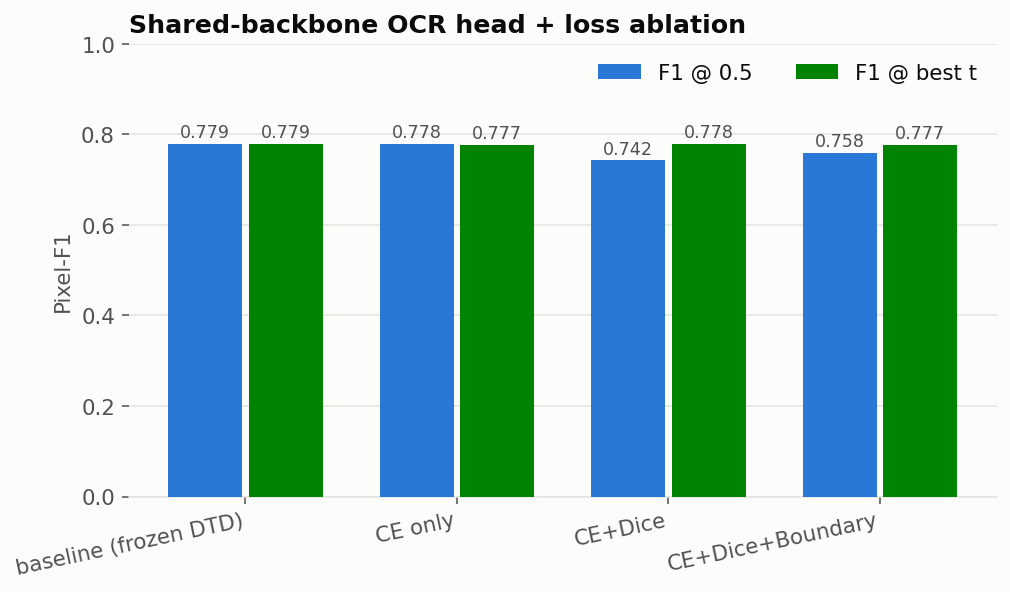

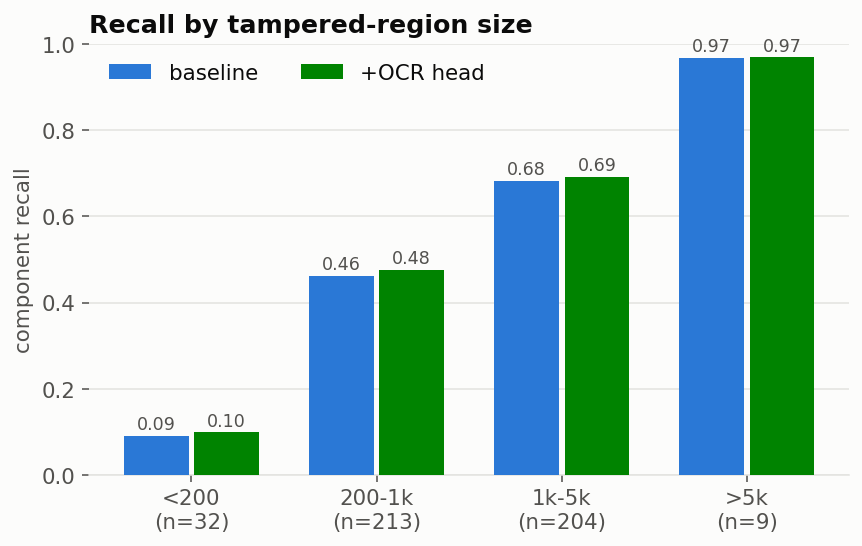

saved -> /content/drive/MyDrive/HLCV_samira/ta_design


In [14]:
# --- Save tables + figures ---
import matplotlib as mpl, matplotlib.pyplot as plt
SURFACE, INK, INK2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e3e3e0'
SERIES = ['#2a78d6', '#008300', '#e87ba4', '#eda100']
FIGS = OUT / 'figures'; FIGS.mkdir(parents=True, exist_ok=True)
mpl.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
                     'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.edgecolor': GRID, 'axes.linewidth': .8, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'legend.frameon': False,
                     'figure.dpi': 140, 'savefig.dpi': 220, 'savefig.bbox': 'tight'})
def style(ax, ylabel=None, ymax=1.0):
    for sp in ('top', 'right', 'left'): ax.spines[sp].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=.8); ax.set_axisbelow(True); ax.set_ylim(0, ymax)
    if ylabel: ax.set_ylabel(ylabel)

COLS = ['pixel_f1', 'f1_at_best_threshold', 'precision', 'recall', 'iou', 'auc']
lines = ['# Results — TrainingSet(2000/200) -> TestingSet(200), seed 42', '',
         '| arm | ' + ' | '.join(COLS) + ' |', '|' + '---|' * (len(COLS) + 1)]
for k, v in results.items():
    lines.append(f'| {k} | ' + ' | '.join(f'{v[c]:.4f}' for c in COLS) + ' |')
lines += ['', '## OCR module (test split)', '']
lines += [f'- {k}: {v:.4f}' for k, v in ocr_report.items()]
lines += ['', '## Recall by tampered-region size', '', '| size | n | baseline | +OCR head |', '|---|---|---|---|']
for nm, (n, rb), (_, ro) in zip(NAMES, base_bd, ocr_bd):
    lines.append(f'| {nm} | {n} | {rb:.4f} | {ro:.4f} |')
(OUT / 'results.md').write_text('\n'.join(lines) + '\n')

arms = list(results.keys())
short = [a.replace('+OCR head, ', '') for a in arms]
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(arms)); w = 0.38
for i, (lab, key) in enumerate([('F1 @ 0.5', 'pixel_f1'), ('F1 @ best t', 'f1_at_best_threshold')]):
    vals = [results[a][key] for a in arms]
    b = ax.bar(x + (i - .5) * w, vals, width=w * .92, color=SERIES[i], label=lab, zorder=3)
    for r, v in zip(b, vals):
        ax.text(r.get_x() + r.get_width() / 2, v + .015, f'{v:.3f}', ha='center', fontsize=9, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(short, rotation=12, ha='right'); ax.legend(ncol=2)
style(ax, 'Pixel-F1'); ax.set_title('Shared-backbone OCR head + loss ablation')
for e in ('png', 'svg'): fig.savefig(FIGS / f'fig1_results.{e}')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
xb = np.arange(len(NAMES))
for i, (lab, bd) in enumerate([('baseline', base_bd), ('+OCR head', ocr_bd)]):
    vals = [v for _, v in bd]
    b = ax.bar(xb + (i - .5) * w, vals, width=w * .92, color=SERIES[i], label=lab, zorder=3)
    for r, v in zip(b, vals):
        if np.isfinite(v): ax.text(r.get_x() + r.get_width() / 2, v + .015, f'{v:.2f}', ha='center', fontsize=9, color=INK2)
ax.set_xticks(xb); ax.set_xticklabels([f'{n}\n(n={c})' for n, (c, _) in zip(NAMES, base_bd)])
ax.legend(ncol=2); style(ax, 'component recall'); ax.set_title('Recall by tampered-region size')
for e in ('png', 'svg'): fig.savefig(FIGS / f'fig2_small_regions.{e}')
plt.show()
print('saved ->', OUT)

/tmp/ipykernel_422/2018946514.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


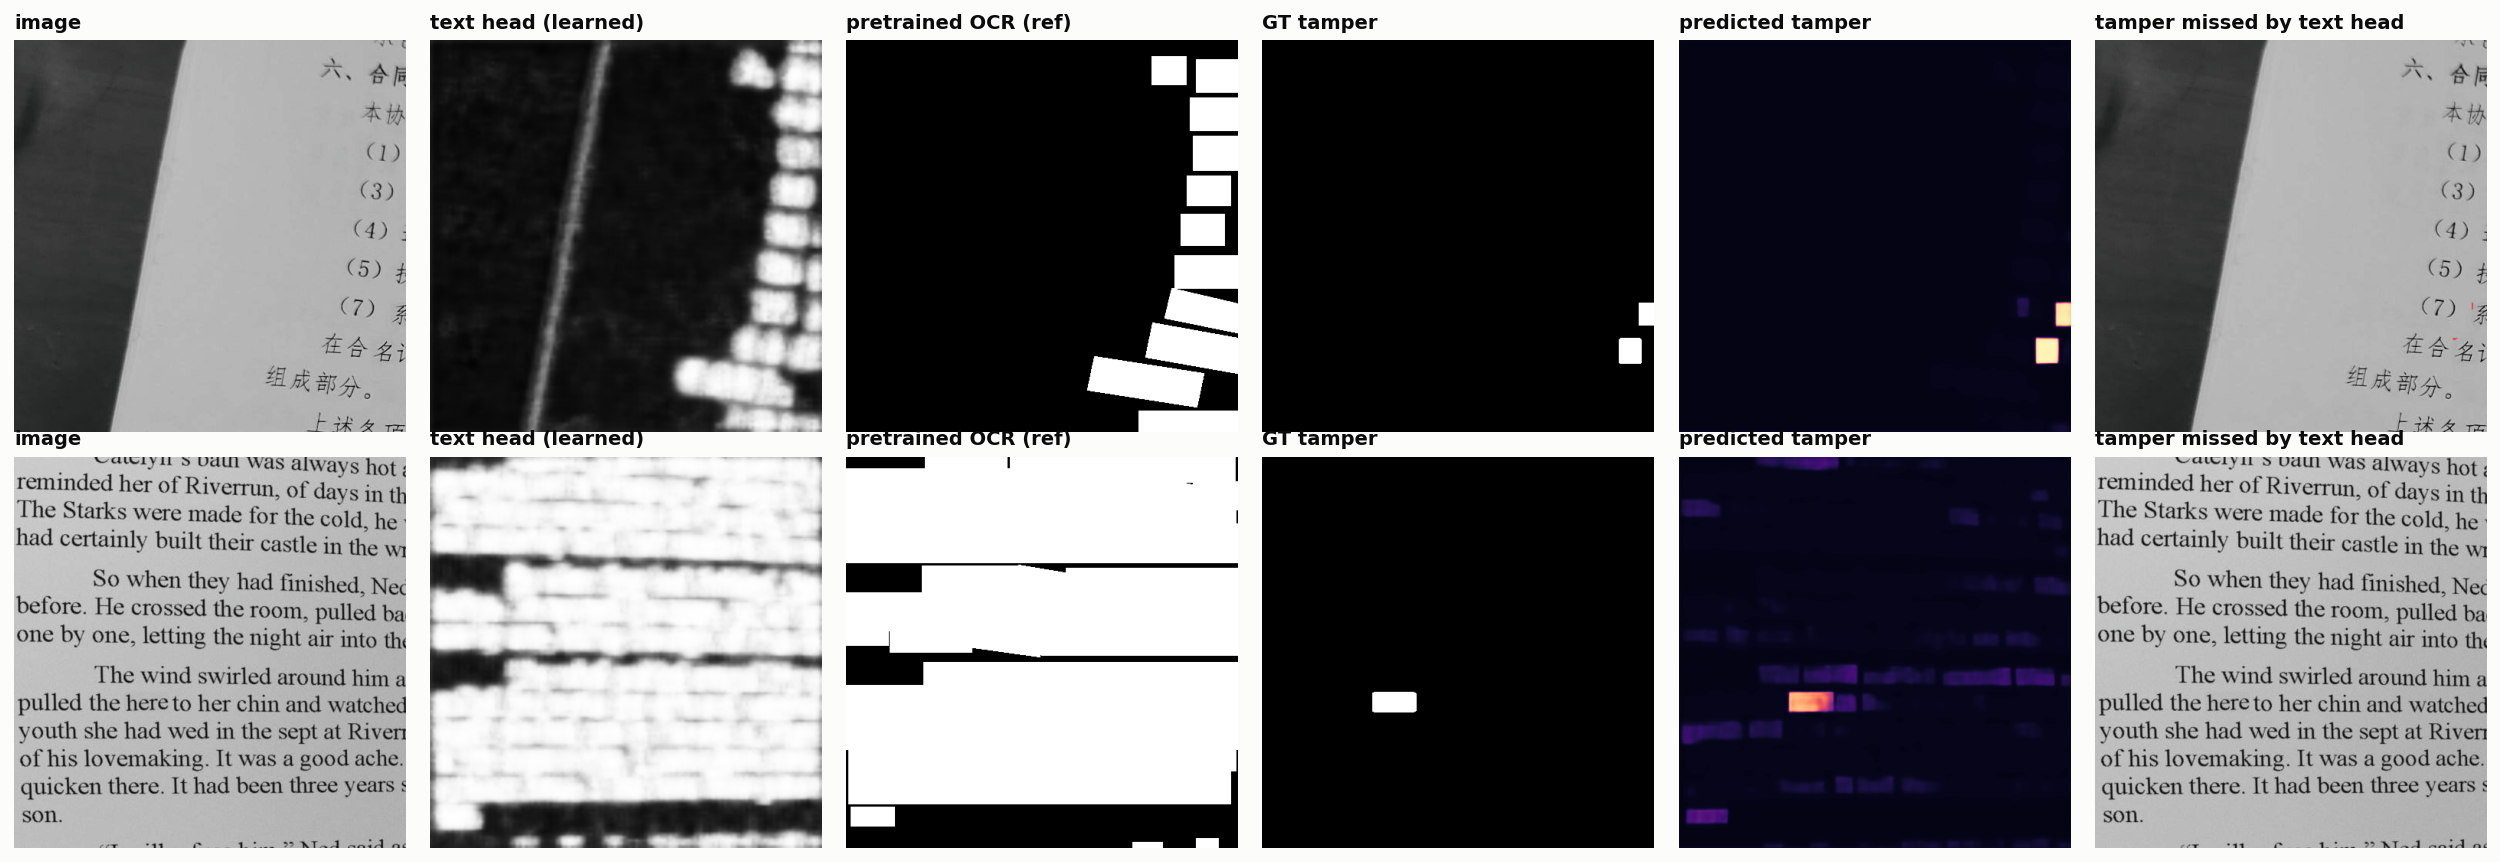


FILES:
   arms/OCR_head_CEDice.pth
   arms/OCR_head_CEDiceBoundary.pth
   arms/OCR_head_CE_only.pth
   ext_arms/E1.pth
   ext_arms/E2.pth
   ext_arms/E3.pth
   ext_arms/E4.pth
   extensions.md
   figures/fig1_results.png
   figures/fig1_results.svg
   figures/fig2_small_regions.png
   figures/fig2_small_regions.svg
   figures/fig3_qualitative.png
   figures/fig3_qualitative.svg
   figures/fig4_extensions.png
   figures/fig4_extensions.svg
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000016.json
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000080.json
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000156.json
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000180.json
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000457.json
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000774.json
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000791.json
   ocr_cache/easyocr_cab25afc609b/DocTamperV1-Testin

In [15]:
# --- Qualitative: image | learned TEXT mask | pretrained OCR | GT tamper | prediction | missed ---
model = build_model(); wire_ocr_head(model, CONFIG['TEXT_FEAT_IDX'], C_VPH)
ck = torch.load(OUT / 'arms' / f"{BEST_ARM.replace(' ', '_').replace('+','').replace(',','')}.pth", map_location='cpu')
model.model.text_head.load_state_dict(ck['text_head'])
model.model.segmentation_head.fusion.load_state_dict(ck['fusion'])
model.eval()

batch = next(iter(test_loader))
with torch.no_grad():
    ref = ocr_masks(batch)[:, 0].cpu().numpy() > 0
    with autocast(enabled=(DEVICE == 'cuda')):
        logits = forward_dtd(model, batch)
        if logits.shape[-2:] != batch['label'].shape[-2:]:
            logits = F.interpolate(logits, size=batch['label'].shape[-2:], mode='bilinear', align_corners=False)
    txt = torch.sigmoid(model.model._text_logits.float())[:, 0].cpu().numpy()
    prob = torch.softmax(logits.float(), 1)[:, 1].cpu().numpy()

n = min(3, len(prob))
fig, axes = plt.subplots(n, 6, figsize=(18, 3.1 * n)); axes = np.atleast_2d(axes)
for i in range(n):
    img = denorm(batch['image'][i]); gt = batch['label'][i, 0].numpy() > 0
    missed = gt & ~(txt[i] > 0.5)
    panels = [(img, 'image', None), (txt[i], 'text head (learned)', 'gray'),
              (ref[i], 'pretrained OCR (ref)', 'gray'), (gt, 'GT tamper', 'gray'),
              (prob[i], 'predicted tamper', 'magma')]
    for j, (im, t, cm) in enumerate(panels):
        axes[i, j].imshow(im, cmap=cm, vmin=0 if cm else None, vmax=1 if cm else None)
        axes[i, j].set_title(t, fontsize=10, loc='left'); axes[i, j].axis('off')
    ov = img.copy(); ov[missed] = np.array([227, 73, 72], np.uint8)
    axes[i, 5].imshow(ov); axes[i, 5].set_title('tamper missed by text head', fontsize=10, loc='left')
    axes[i, 5].axis('off')
fig.tight_layout()
for e in ('png', 'svg'): fig.savefig(FIGS / f'fig3_qualitative.{e}')
plt.show()

print('\nFILES:')
for p in sorted(OUT.rglob('*')):
    if p.is_file() and p.suffix in {'.md', '.json', '.png', '.svg', '.pth'}:
        print('  ', p.relative_to(OUT))

---
# Extensions — three hypotheses for why the prior didn't help

The main result showed the prior is **not** the bottleneck: the learned head reaches 0.98 component
recall, yet F1@best is identical across all arms (0.776-0.779). Three candidate explanations, each
tested in isolation and then combined:

| # | Hypothesis | Change |
|---|---|---|
| **E1** | Injected too late - at the final decoder output there is no network left to exploit it | Fuse into the **VPH pyramid** (`feat[1]`, 192 ch) so FU -> Swin -> MID decoder all see it |
| **E2** | Everything frozen, so the model cannot *learn* to use the prior | **Unfreeze the MID decoder** (encoder stays frozen; BN stats stay frozen) |
| **E3** | Dice traded recall away; small forgeries (<200 px) sit at 0.09 recall | **Tversky loss** (beta>alpha) penalising false negatives explicitly |
| **E4** | - | All three combined |

Steps raised to **1000 = one full epoch** over the 2000 training images. The main run used 600 steps
= 1200 samples, i.e. **less than one epoch - it was step-limited, not data-limited**, which is why
simply adding more data would not have helped.

In [16]:
# === EXTENSIONS: components (deep injection, decoder unfreeze, Tversky) ======================
from src.losses import boundary_loss, IGNORE_INDEX

EXT_STEPS = 1000          # one full epoch over the 2000 training images
DECODER_LR = 1e-5         # lower LR for the pretrained decoder than for the new modules
DEEP_IDX = (1,)           # which VPH pyramid level(s) receive the prior (feat[1] = 192ch @64x64)

# --- E3: Tversky (beta > alpha penalises FALSE NEGATIVES -> recall-oriented) ---
def tversky_loss(logits, target, alpha=0.3, beta=0.7, ignore_index=IGNORE_INDEX, eps=1.0):
    prob = torch.softmax(logits, 1)[:, 1]
    valid = (target != ignore_index).float()
    fg = (target == 1).float() * valid
    prob = prob * valid
    d = (1, 2)
    tp = (prob * fg).sum(d)
    fp = (prob * (1 - fg)).sum(d)
    fn = ((1 - prob) * fg).sum(d)
    return (1 - (tp + eps) / (tp + alpha * fp + beta * fn + eps)).mean()

class CombinedTverskyLoss(nn.Module):
    """CE + lambda_tv * Tversky (+ optional boundary). Recall-oriented replacement for Dice."""
    def __init__(self, lambda_tv=1.0, alpha=0.3, beta=0.7, lambda_bound=0.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
        self.lt, self.a, self.b, self.lb = lambda_tv, alpha, beta, lambda_bound
    def forward(self, logits, target):
        target = target.long()
        ce = self.ce(logits, target)
        tv = tversky_loss(logits, target, self.a, self.b)
        bd = boundary_loss(logits, target) if self.lb else torch.zeros((), device=logits.device)
        total = ce + self.lt * tv + self.lb * bd
        return total, {'total': total.detach(), 'ce': ce.detach(),
                       'dice': tv.detach(), 'boundary': bd.detach()}

# --- VPH channel widths (re-probed so this cell is self-contained) ---
_m = build_model()
VPH_CH = [f.shape[1] for f in probe_vph(_m)]
del _m; torch.cuda.empty_cache()
print('VPH channels:', VPH_CH)

def identity_init(fus):
    """Zero the residual branch and make the merge linear -> module starts as exact identity."""
    nn.init.zeros_(fus.block[-1].weight); nn.init.zeros_(fus.block[-1].bias)
    fus.act = nn.Identity()

# --- E1: deep injection. A forward hook that RETURNS a modified feature list replaces the
# VPH output, so FU -> Swin -> MID decoder all operate on prior-enhanced features. ---
def wire_advanced(model, deep_idx=(), unfreeze_decoder=False):
    core = model.model
    if hasattr(core, '_ta_hook'):
        core._ta_hook.remove()
    core.text_head = TextHead(VPH_CH[CONFIG['TEXT_FEAT_IDX']]).to(DEVICE)

    head = core.segmentation_head                      # late fusion (as in the main experiment)
    while hasattr(head, 'head'):
        head = head.head
    hp = HeadWithPrior(head, head[0].in_channels).to(DEVICE)
    identity_init(hp.fusion)
    core.segmentation_head = hp

    core.deep_fusions = nn.ModuleDict()                # deep fusions, one per chosen level
    for k in deep_idx:
        f = TextPriorFusion(VPH_CH[k]).to(DEVICE)
        identity_init(f)
        core.deep_fusions[str(k)] = f

    def hook(m, i, o):
        fl = list(o) if isinstance(o, (list, tuple)) else [o]
        t = core.text_head(fl[CONFIG['TEXT_FEAT_IDX']])      # read the ORIGINAL features
        t = F.interpolate(t, size=(IMG, IMG), mode='bilinear', align_corners=False)
        core._text_logits = t
        mask = torch.sigmoid(t)
        core.segmentation_head.text_mask = mask
        for k, fus in core.deep_fusions.items():             # inject into the pyramid
            fl[int(k)] = fus(fl[int(k)], mask)
        return fl                                            # replaces the VPH output
    core._ta_hook = core.vph.register_forward_hook(hook)
    core._unfrozen_decoder = unfreeze_decoder
    return core

# --- E2: parameter groups. Encoder always frozen; decoder optionally trainable at a lower LR. ---
def adv_param_groups(model, unfreeze_decoder):
    core = model.model
    for p in model.parameters():
        p.requires_grad_(False)
    new_mods = [core.text_head, core.segmentation_head.fusion] + list(core.deep_fusions.values())
    for mm in new_mods:
        for p in mm.parameters():
            p.requires_grad_(True)
    groups = [{'params': [p for mm in new_mods for p in mm.parameters()], 'lr': CONFIG['ADAPTER_LR']}]
    if unfreeze_decoder:
        for p in core.decoder.parameters():
            p.requires_grad_(True)
        groups.append({'params': list(core.decoder.parameters()), 'lr': DECODER_LR})
    n = sum(p.numel() for g in groups for p in g['params'])
    return groups, n

def adv_train_mode(model):
    """model.eval() keeps EVERY BatchNorm's running stats frozen (including the decoder, whose
    weights may still be training) -- with batch size 2, updating them destabilises the model."""
    core = model.model
    model.eval()
    core.text_head.train()
    core.segmentation_head.fusion.train()
    for f in core.deep_fusions.values():
        f.train()

def train_advanced(model, criterion, steps, unfreeze_decoder, tag=''):
    core = model.model
    groups, n_tr = adv_param_groups(model, unfreeze_decoder)
    opt = torch.optim.AdamW(groups, weight_decay=CONFIG['WEIGHT_DECAY'])
    scaler = GradScaler(); it = iter(train_loader)

    m0, _, _ = evaluate(model, val_loader)
    def snap():
        s = {'text': copy.deepcopy(core.text_head.state_dict()),
             'fus': copy.deepcopy(core.segmentation_head.fusion.state_dict()),
             'deep': copy.deepcopy(core.deep_fusions.state_dict())}
        if unfreeze_decoder:
            s['dec'] = copy.deepcopy(core.decoder.state_dict())
        return s
    best = {'f1': m0['pixel_f1'], 'step': 0, 'state': snap()}
    print(f"  [{tag}] trainable {n_tr:,} | val@0000 f1={m0['pixel_f1']:.4f}")
    stale = 0
    adv_train_mode(model)
    for step in range(steps):
        try: batch = next(it)
        except StopIteration: it = iter(train_loader); batch = next(it)
        pseudo = ocr_masks(batch)
        target = batch['label'].squeeze(1).long().to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            tamper_loss, parts = criterion(logits, target)
            text_loss = bce(core._text_logits.float(), pseudo)
            loss = tamper_loss + CONFIG['LAMBDA_TEXT'] * text_loss
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        if (step + 1) % CONFIG['EVAL_EVERY'] == 0:
            m, _, _ = evaluate(model, val_loader)
            better = m['pixel_f1'] > best['f1']
            print(f"  [{tag}] val@{step+1:04d} f1={m['pixel_f1']:.4f} tamper={float(parts['total']):.4f} "
                  f"text={text_loss.item():.4f}{'  <- best' if better else ''}")
            if better:
                best = {'f1': m['pixel_f1'], 'step': step + 1, 'state': snap()}; stale = 0
            else:
                stale += 1
                if stale >= CONFIG['PATIENCE']:
                    print(f'  [{tag}] early stop at {step+1}'); break
            adv_train_mode(model)
    core.text_head.load_state_dict(best['state']['text'])
    core.segmentation_head.fusion.load_state_dict(best['state']['fus'])
    core.deep_fusions.load_state_dict(best['state']['deep'])
    if unfreeze_decoder:
        core.decoder.load_state_dict(best['state']['dec'])
    print(f"  [{tag}] restored step {best['step']} (val f1={best['f1']:.4f})")
    return best

print('extension components ready')

  vph feat[0] channels=96 spatial=(128, 128)
  vph feat[1] channels=192 spatial=(64, 64)
  vph feat[2] channels=384 spatial=(32, 32)
  vph feat[3] channels=768 spatial=(16, 16)
VPH channels: [96, 192, 384, 768]
extension components ready


In [17]:
# === EXTENSIONS: run E1-E4 ====================================================================
# Each row isolates one hypothesis; E4 combines them. Same data, seed, and steps throughout.
EXT_CONFIGS = {
    'E1 deep injection':      dict(deep=DEEP_IDX, unfreeze=False, loss='ce'),
    'E2 unfreeze decoder':    dict(deep=(),       unfreeze=True,  loss='ce'),
    'E3 Tversky loss':        dict(deep=(),       unfreeze=False, loss='tversky'),
    'E4 all three':           dict(deep=DEEP_IDX, unfreeze=True,  loss='tversky'),
}

def make_criterion(kind):
    if kind == 'tversky':
        return CombinedTverskyLoss(lambda_tv=1.0, alpha=0.3, beta=0.7, lambda_bound=0.5)
    return CombinedTamperLoss(lambda_dice=0.0, lambda_bound=0.0)      # plain CE

ext_results = {'baseline (frozen DTD)': results['baseline (frozen DTD)']}
ext_curves = {'baseline (frozen DTD)': curves['baseline (frozen DTD)']}
(OUT / 'ext_arms').mkdir(parents=True, exist_ok=True)

for tag, cfg in EXT_CONFIGS.items():
    print(f"\n=== {tag}  (deep={cfg['deep']}, unfreeze_decoder={cfg['unfreeze']}, loss={cfg['loss']}) ===")
    model = build_model()
    wire_advanced(model, deep_idx=cfg['deep'], unfreeze_decoder=cfg['unfreeze'])
    crit = make_criterion(cfg['loss'])
    best = train_advanced(model, crit, EXT_STEPS, cfg['unfreeze'], tag=tag.split()[0])
    met, y, s = evaluate(model, test_loader)
    ext_results[tag], ext_curves[tag] = met, (y, s)
    torch.save({'text_head': model.model.text_head.state_dict(),
                'fusion': model.model.segmentation_head.fusion.state_dict(),
                'deep': model.model.deep_fusions.state_dict(),
                'decoder': model.model.decoder.state_dict() if cfg['unfreeze'] else None},
               OUT / 'ext_arms' / f"{tag.split()[0]}.pth")
    print(' TEST:', {k: round(v, 4) for k, v in met.items()})
    del model; torch.cuda.empty_cache()


=== E1 deep injection  (deep=(1,), unfreeze_decoder=False, loss=ce) ===


/tmp/ipykernel_422/740201098.py:112: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(train_loader)
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [E1] trainable 505,409 | val@0000 f1=0.6100


/tmp/ipykernel_422/740201098.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [E1] val@0100 f1=0.6063 tamper=0.1052 text=0.4192


...

  [E4] val@0300 f1=0.6190 tamper=1.4180 text=0.2689


/tmp/ipykernel_422/740201098.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [E4] val@0400 f1=0.6155 tamper=0.9173 text=0.4015
  [E4] early stop at 400
  [E4] restored step 100 (val f1=0.6311)


/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.7575, 'precision': 0.779, 'recall': 0.7371, 'iou': 0.6096, 'auc': 0.9712}


arm                          F1@0.5   F1@best  best_t    prec     rec      IoU      AUC
baseline (frozen DTD)        0.7795    0.7787    0.55  0.8662  0.7085   0.6387   0.9454
E1 deep injection            0.7758    0.7756    0.55  0.8652  0.7031   0.6337   0.9766
E2 unfreeze decoder          0.7608    0.7605    0.55  0.8298  0.7023   0.6139   0.9777
E3 Tversky loss              0.7468    0.7760    0.80  0.7465  0.7470   0.5959   0.9155
E4 all three                 0.7575    0.7764    0.75  0.7790  0.7371   0.6096   0.9712

best extension: E4 all three  (F1@best 0.7764 vs baseline 0.7787, delta -0.0023)
NOTE: run-to-run noise is ~+/-0.005 F1; a delta smaller than that is not an effect.


/tmp/ipykernel_422/2956090247.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):



    size     n   baseline   main +OCR   best ext
    <200    32     0.0917      0.0993     0.1122
  200-1k   213     0.4616      0.4756     0.5056
   1k-5k   204     0.6826      0.6921     0.7256
     >5k     9     0.9676      0.9689     0.9782


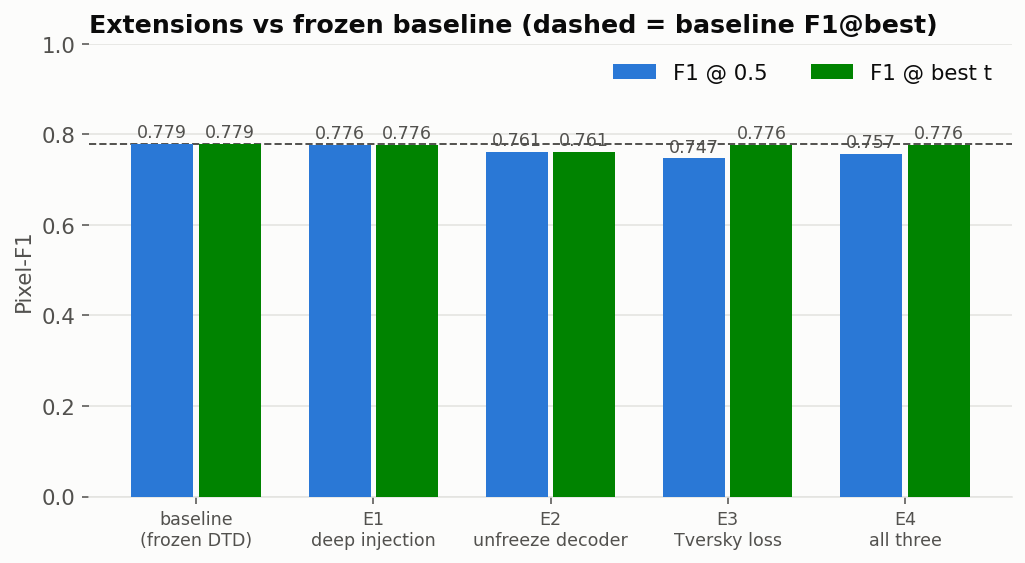

saved -> /content/drive/MyDrive/HLCV_samira/ta_design/extensions.md


In [18]:
# === EXTENSIONS: threshold sweep, small-region breakdown, save ================================
for name, (y, s) in ext_curves.items():
    f1s = []
    for t in THRESHOLDS:
        pred = s >= t
        tp = int((pred & (y == 1)).sum()); fp = int((pred & (y == 0)).sum()); fn = int((~pred & (y == 1)).sum())
        p = tp / (tp + fp + 1e-9); r = tp / (tp + fn + 1e-9)
        f1s.append(2 * p * r / (p + r + 1e-9))
    f1s = np.array(f1s); b = int(f1s.argmax())
    ext_results[name]['f1_at_best_threshold'] = float(f1s[b])
    ext_results[name]['best_threshold'] = float(THRESHOLDS[b])

print(f'{"arm":<26}{"F1@0.5":>9}{"F1@best":>10}{"best_t":>8}{"prec":>8}{"rec":>8}{"IoU":>9}{"AUC":>9}')
for k, v in ext_results.items():
    print(f"{k:<26}{v['pixel_f1']:>9.4f}{v['f1_at_best_threshold']:>10.4f}{v['best_threshold']:>8.2f}"
          f"{v['precision']:>8.4f}{v['recall']:>8.4f}{v['iou']:>9.4f}{v['auc']:>9.4f}")

BASE_F1 = ext_results['baseline (frozen DTD)']['f1_at_best_threshold']
EXT_BEST = max((k for k in ext_results if k != 'baseline (frozen DTD)'),
               key=lambda k: ext_results[k]['f1_at_best_threshold'])
print(f"\nbest extension: {EXT_BEST}  (F1@best {ext_results[EXT_BEST]['f1_at_best_threshold']:.4f} "
      f"vs baseline {BASE_F1:.4f}, delta {ext_results[EXT_BEST]['f1_at_best_threshold']-BASE_F1:+.4f})")
print('NOTE: run-to-run noise is ~+/-0.005 F1; a delta smaller than that is not an effect.')

# --- Small-region recall for the best extension (the proposal's core motivation) ---
cfg = EXT_CONFIGS[EXT_BEST]
m = build_model()
wire_advanced(m, deep_idx=cfg['deep'], unfreeze_decoder=cfg['unfreeze'])
ck = torch.load(OUT / 'ext_arms' / f"{EXT_BEST.split()[0]}.pth", map_location='cpu')
m.model.text_head.load_state_dict(ck['text_head'])
m.model.segmentation_head.fusion.load_state_dict(ck['fusion'])
m.model.deep_fusions.load_state_dict(ck['deep'])
if ck.get('decoder') is not None:
    m.model.decoder.load_state_dict(ck['decoder'])
ext_bd = region_breakdown(m)
del m; torch.cuda.empty_cache()

print(f'\n{"size":>8}{"n":>6}{"baseline":>11}{"main +OCR":>12}{"best ext":>11}')
for nm, (n, rb), (_, ro), (_, re_) in zip(NAMES, base_bd, ocr_bd, ext_bd):
    print(f'{nm:>8}{n:>6}{rb:>11.4f}{ro:>12.4f}{re_:>11.4f}')

# --- Save ---
COLS2 = ['pixel_f1', 'f1_at_best_threshold', 'best_threshold', 'precision', 'recall', 'iou', 'auc']
lines = ['# Extensions — deep injection / decoder unfreeze / Tversky', '',
         f'{EXT_STEPS} steps (1 epoch over {CONFIG["TRAIN_SIZE"]} images), seed {CONFIG["SEED"]}', '',
         '| arm | ' + ' | '.join(COLS2) + ' |', '|' + '---|' * (len(COLS2) + 1)]
for k, v in ext_results.items():
    lines.append(f'| {k} | ' + ' | '.join(f'{v[c]:.4f}' for c in COLS2) + ' |')
lines += ['', '## Recall by tampered-region size', '',
          '| size | n | baseline | main +OCR | best ext |', '|---|---|---|---|---|']
for nm, (n, rb), (_, ro), (_, re_) in zip(NAMES, base_bd, ocr_bd, ext_bd):
    lines.append(f'| {nm} | {n} | {rb:.4f} | {ro:.4f} | {re_:.4f} |')
(OUT / 'extensions.md').write_text('\n'.join(lines) + '\n')

fig, ax = plt.subplots(figsize=(8.5, 4.2))
arms2 = list(ext_results.keys())
x = np.arange(len(arms2)); w = 0.38
for i, (lab, key) in enumerate([('F1 @ 0.5', 'pixel_f1'), ('F1 @ best t', 'f1_at_best_threshold')]):
    vals = [ext_results[a][key] for a in arms2]
    b = ax.bar(x + (i - .5) * w, vals, width=w * .92, color=SERIES[i], label=lab, zorder=3)
    for r, v in zip(b, vals):
        ax.text(r.get_x() + r.get_width() / 2, v + .015, f'{v:.3f}', ha='center', fontsize=9, color=INK2)
ax.axhline(BASE_F1, color=INK2, linewidth=1, linestyle='--', zorder=2)
ax.set_xticks(x); ax.set_xticklabels([a.replace(' ', '\n', 1) for a in arms2], fontsize=9)
ax.legend(ncol=2); style(ax, 'Pixel-F1')
ax.set_title('Extensions vs frozen baseline (dashed = baseline F1@best)')
for e in ('png', 'svg'):
    fig.savefig(FIGS / f'fig4_extensions.{e}')
plt.show()
print('saved ->', OUT / 'extensions.md')

---
## Loss-weight sweep and seed variance

Two final checks:

* **lambda sweep** - selected on **val**, reported on **test**. Closes the "did you tune the loss
  weights?" question, and simultaneously measures how well val-selection transfers (in the main run
  val rose 0.610 -> 0.631 while test did not move, because val comes from TrainingSet and test from
  TestingSet). A small interpretable grid is used rather than Bayesian optimisation, which would
  drive hard into a 200-image val set that is a weak proxy for test.
* **3 seeds** - converts "a delta of -0.003 is within noise" into a *measured* noise floor with
  error bars. The frozen baseline is untrained and therefore deterministic (std = 0).

In [19]:
# === EXTENSIONS: lambda sweep — SELECT ON VAL, REPORT ON TEST =================================
# Closes the "did you tune the loss weights?" question. Note the caveat this run also measures:
# val comes from TrainingSet while test comes from TestingSet, so val is a weak proxy for test
# (in the main run val rose 0.610 -> 0.631 while test did not move). That is exactly why we use a
# small interpretable grid here rather than Bayesian optimisation, which would drive hard into val.
GRID_STEPS = 600                      # same budget as the main run, so numbers are comparable

def f1_best(y, s):
    """Best F1 over the threshold grid, and the threshold that achieves it."""
    bf, bt = 0.0, 0.5
    for t in THRESHOLDS:
        pred = s >= t
        tp = int((pred & (y == 1)).sum()); fp = int((pred & (y == 0)).sum()); fn = int((~pred & (y == 1)).sum())
        p = tp / (tp + fp + 1e-9); r = tp / (tp + fn + 1e-9)
        f = 2 * p * r / (p + r + 1e-9)
        if f > bf: bf, bt = f, float(t)
    return bf, bt

def run_lambda_cfg(ld, lb, lt, steps=GRID_STEPS, tag=''):
    """One frozen-backbone run with the given loss weights. Returns (val_f1, test metrics)."""
    prev_lt = CONFIG['LAMBDA_TEXT']
    CONFIG['LAMBDA_TEXT'] = lt                      # train_advanced reads this
    try:
        model = build_model()
        wire_advanced(model, deep_idx=(), unfreeze_decoder=False)
        crit = CombinedTamperLoss(lambda_dice=ld, lambda_bound=lb)
        best = train_advanced(model, crit, steps, False, tag=tag)
        met, y, s = evaluate(model, test_loader)
        met['f1_at_best_threshold'], met['best_threshold'] = f1_best(y, s)
        del model; torch.cuda.empty_cache()
        return best['f1'], met
    finally:
        CONFIG['LAMBDA_TEXT'] = prev_lt

# Stage 1: the (dice, boundary) grid at the default lambda_text
LAMBDA_GRID = [
    ('ld=0.0 lb=0.0', 0.0, 0.0, 0.5),
    ('ld=1.0 lb=0.0', 1.0, 0.0, 0.5),
    ('ld=0.0 lb=0.5', 0.0, 0.5, 0.5),
    ('ld=1.0 lb=0.5', 1.0, 0.5, 0.5),
]
lam_results = {}
for name, ld, lb, lt in LAMBDA_GRID:
    print(f'\n=== lambda grid: {name} (lambda_text={lt}) ===')
    v, m = run_lambda_cfg(ld, lb, lt, tag=name)
    lam_results[f'{name} lt={lt}'] = {'val_f1': v, **m, 'ld': ld, 'lb': lb, 'lt': lt}

# Stage 2: vary lambda_text at the val-best (dice, boundary)
best_key = max(lam_results, key=lambda k: lam_results[k]['val_f1'])
bld, blb = lam_results[best_key]['ld'], lam_results[best_key]['lb']
print(f'\nval-best loss weights: ld={bld} lb={blb} -> now sweeping lambda_text')
for lt in (0.1, 1.0):
    name = f'ld={bld} lb={blb}'
    print(f'\n=== lambda grid: {name} (lambda_text={lt}) ===')
    v, m = run_lambda_cfg(bld, blb, lt, tag=f'lt={lt}')
    lam_results[f'{name} lt={lt}'] = {'val_f1': v, **m, 'ld': bld, 'lb': blb, 'lt': lt}

# --- Table: does val-selection transfer to test? ---
base_best = ext_results['baseline (frozen DTD)']['f1_at_best_threshold']
print(f'\n{"config":<26}{"VAL f1":>9}{"TEST@0.5":>10}{"TEST@best":>11}{"best_t":>8}{"vs base":>9}')
for k, v in sorted(lam_results.items(), key=lambda kv: -kv[1]['val_f1']):
    print(f"{k:<26}{v['val_f1']:>9.4f}{v['pixel_f1']:>10.4f}{v['f1_at_best_threshold']:>11.4f}"
          f"{v['best_threshold']:>8.2f}{v['f1_at_best_threshold']-base_best:>+9.4f}")
print(f'\nbaseline (frozen DTD) TEST F1@best = {base_best:.4f}')
sel = max(lam_results, key=lambda k: lam_results[k]['val_f1'])
print(f"val-selected config: {sel} -> TEST F1@best {lam_results[sel]['f1_at_best_threshold']:.4f} "
      f"({lam_results[sel]['f1_at_best_threshold']-base_best:+.4f} vs baseline)")


=== lambda grid: ld=0.0 lb=0.0 (lambda_text=0.5) ===


/tmp/ipykernel_422/740201098.py:112: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(train_loader)
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [ld=0.0 lb=0.0] trainable 134,273 | val@0000 f1=0.6100


/tmp/ipykernel_422/740201098.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [ld=0.0 lb=0.0] val@0100 f1=0.6110 tamper=0.0836 text=0.4337  <- best


...

  [lt=1.0] val@0400 f1=0.6286 tamper=0.8530 text=0.2477


/tmp/ipykernel_422/740201098.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [lt=1.0] val@0500 f1=0.6147 tamper=1.0521 text=0.3021
  [lt=1.0] early stop at 500
  [lt=1.0] restored step 200 (val f1=0.6308)


/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):



config                       VAL f1  TEST@0.5  TEST@best  best_t  vs base
ld=1.0 lb=0.0 lt=1.0         0.6308    0.7486     0.7777    0.75  -0.0010
ld=1.0 lb=0.0 lt=0.5         0.6299    0.7418     0.7787    0.75  +0.0000
ld=1.0 lb=0.5 lt=0.5         0.6296    0.7637     0.7756    0.70  -0.0031
ld=1.0 lb=0.0 lt=0.1         0.6272    0.7694     0.7783    0.60  -0.0004
ld=0.0 lb=0.5 lt=0.5         0.6218    0.7760     0.7779    0.60  -0.0007
ld=0.0 lb=0.0 lt=0.5         0.6187    0.7773     0.7783    0.55  -0.0003

baseline (frozen DTD) TEST F1@best = 0.7787
val-selected config: ld=1.0 lb=0.0 lt=1.0 -> TEST F1@best 0.7777 (-0.0010 vs baseline)



=== seed 42 | +OCR head (CE) ===


/tmp/ipykernel_422/740201098.py:112: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(train_loader)
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [s42] trainable 134,273 | val@0000 f1=0.6100


/tmp/ipykernel_422/740201098.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [s42] val@0100 f1=0.6181 tamper=0.0936 text=0.3325  <- best


...

  [s44] val@0500 f1=0.6303 tamper=1.0320 text=0.1957  <- best


/tmp/ipykernel_422/740201098.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  [s44] val@0600 f1=0.6302 tamper=0.9168 text=0.4779
  [s44] restored step 500 (val f1=0.6303)


/tmp/ipykernel_422/3238522890.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.7472, 'precision': 0.7494, 'recall': 0.7449, 'iou': 0.5964, 'auc': 0.9168, 'f1_at_best_threshold': 0.7751, 'best_threshold': 0.8}

arm                     F1@best mean     std    95% CI  vs baseline
baseline (frozen DTD)         0.7787  0.0000    0.0000      +0.0000
+OCR head (CE)                0.7785  0.0007    0.0017      -0.0002  n.s.
E3 Tversky                    0.7762  0.0011    0.0027      -0.0024  n.s.

MEASURED noise floor (max seed std) = 0.0011 F1  -> differences smaller than ~0.002 are not meaningful.


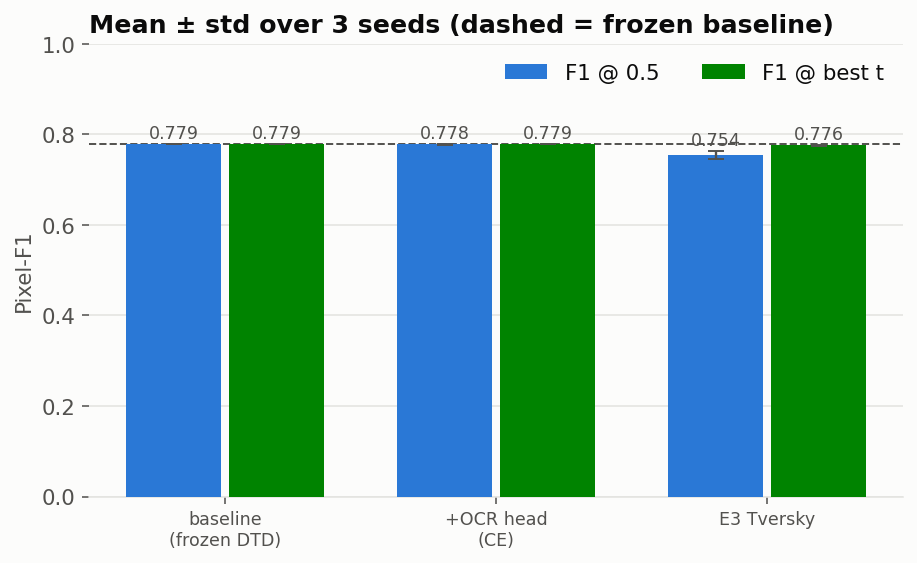

saved -> /content/drive/MyDrive/HLCV_samira/ta_design/lambda_and_seeds.md


In [20]:
# === EXTENSIONS: multi-seed runs -> measured noise floor + error-bar plot =====================
# Turns "a delta of -0.003 is within noise" from an assertion into a measured number.
# The baseline is FROZEN and untrained, so it is deterministic (std = 0 by construction);
# only the trained arms vary with the seed.
SEEDS = [42, 43, 44]
SEED_STEPS = 600

SEED_CONFIGS = {
    '+OCR head (CE)':  dict(ld=0.0, lb=0.0, lt=0.5, loss='ce'),
    'E3 Tversky':      dict(ld=None, lb=0.5, lt=0.5, loss='tversky'),
}

seed_runs = {k: [] for k in SEED_CONFIGS}
for seed in SEEDS:
    for name, cfg in SEED_CONFIGS.items():
        torch.manual_seed(seed); np.random.seed(seed)
        print(f'\n=== seed {seed} | {name} ===')
        crit = (CombinedTverskyLoss(lambda_tv=1.0, alpha=0.3, beta=0.7, lambda_bound=cfg['lb'])
                if cfg['loss'] == 'tversky'
                else CombinedTamperLoss(lambda_dice=cfg['ld'], lambda_bound=cfg['lb']))
        model = build_model()
        wire_advanced(model, deep_idx=(), unfreeze_decoder=False)
        train_advanced(model, crit, SEED_STEPS, False, tag=f's{seed}')
        met, y, s = evaluate(model, test_loader)
        met['f1_at_best_threshold'], met['best_threshold'] = f1_best(y, s)
        seed_runs[name].append(met)
        print(' TEST:', {k: round(v, 4) for k, v in met.items()})
        del model; torch.cuda.empty_cache()

# --- Aggregate: mean +/- std, and a t-based 95% CI (n=3 -> t=4.303) ---
T95 = 4.303
def agg(vals):
    a = np.array(vals, dtype=float)
    m, sd = a.mean(), a.std(ddof=1)
    return m, sd, T95 * sd / np.sqrt(len(a))

base_m = ext_results['baseline (frozen DTD)']['f1_at_best_threshold']
base_05 = ext_results['baseline (frozen DTD)']['pixel_f1']
summary = {'baseline (frozen DTD)': {'f1_best': (base_m, 0.0, 0.0), 'f1_05': (base_05, 0.0, 0.0)}}
for name, runs in seed_runs.items():
    summary[name] = {'f1_best': agg([r['f1_at_best_threshold'] for r in runs]),
                     'f1_05':   agg([r['pixel_f1'] for r in runs])}

print(f'\n{"arm":<22}{"F1@best mean":>14}{"std":>8}{"95% CI":>10}{"vs baseline":>13}')
for k, v in summary.items():
    m, sd, ci = v['f1_best']
    d = m - base_m
    verdict = '' if k.startswith('baseline') else ('  SIGNIFICANT' if abs(d) > ci and ci > 0 else '  n.s.')
    print(f'{k:<22}{m:>14.4f}{sd:>8.4f}{ci:>10.4f}{d:>+13.4f}{verdict}')

noise = max(v['f1_best'][1] for k, v in summary.items() if not k.startswith('baseline'))
print(f'\nMEASURED noise floor (max seed std) = {noise:.4f} F1'
      f'  -> differences smaller than ~{2*noise:.3f} are not meaningful.')

# --- Plot with error bars ---
fig, ax = plt.subplots(figsize=(7.5, 4.2))
arms = list(summary.keys())
x = np.arange(len(arms)); w = 0.38
for i, (lab, key) in enumerate([('F1 @ 0.5', 'f1_05'), ('F1 @ best t', 'f1_best')]):
    means = [summary[a][key][0] for a in arms]
    errs = [summary[a][key][1] for a in arms]
    b = ax.bar(x + (i - .5) * w, means, width=w * .92, color=SERIES[i], label=lab, zorder=3,
               yerr=errs, capsize=4, error_kw=dict(ecolor=INK2, lw=1.2))
    for r, m_, e_ in zip(b, means, errs):
        ax.text(r.get_x() + r.get_width() / 2, m_ + e_ + .012, f'{m_:.3f}',
                ha='center', fontsize=9, color=INK2)
ax.axhline(base_m, color=INK2, lw=1, ls='--', zorder=2)
ax.set_xticks(x); ax.set_xticklabels([a.replace(' (', '\n(') for a in arms], fontsize=9)
ax.legend(ncol=2); style(ax, 'Pixel-F1')
ax.set_title(f'Mean ± std over {len(SEEDS)} seeds (dashed = frozen baseline)')
for e in ('png', 'svg'):
    fig.savefig(FIGS / f'fig5_seeds.{e}')
plt.show()

# --- Save ---
lines = [f'# Lambda sweep and multi-seed results ({SEED_STEPS} steps, seeds {SEEDS})', '',
         '## Lambda sweep (selected on VAL, reported on TEST)', '',
         '| config | val_f1 | test F1@0.5 | test F1@best | best_t |', '|---|---|---|---|---|']
for k, v in sorted(lam_results.items(), key=lambda kv: -kv[1]['val_f1']):
    lines.append(f"| {k} | {v['val_f1']:.4f} | {v['pixel_f1']:.4f} | "
                 f"{v['f1_at_best_threshold']:.4f} | {v['best_threshold']:.2f} |")
lines += ['', f'Baseline TEST F1@best = {base_m:.4f}', '',
          '## Seed variance', '', '| arm | F1@best mean | std | 95% CI | vs baseline |', '|---|---|---|---|---|']
for k, v in summary.items():
    m, sd, ci = v['f1_best']
    lines.append(f'| {k} | {m:.4f} | {sd:.4f} | +/-{ci:.4f} | {m-base_m:+.4f} |')
lines += ['', f'Measured noise floor (max seed std): {noise:.4f} F1']
(OUT / 'lambda_and_seeds.md').write_text('\n'.join(lines) + '\n')
print('saved ->', OUT / 'lambda_and_seeds.md')